# 📊 Plotting for Machine Learning

📂 `Titanic-Dataset.csv` and `mpg.csv` — keep both in this folder.

Every plot today answers **one question**, and the answer changes what you do next.

**How many columns am I looking at?**

| columns | called | today |
|---|---|---|
| 1 | univariate | `histplot` · `countplot` |
| 2 | bivariate | `boxplot` · `scatterplot` · `hue=` |
| 3+ | multivariate | `pairplot` · `heatmap` |

In [ ]:
! pip3 install matplotlib
! pip3 install seaborn

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/Users/shubhamsingh/Desktop/ML/Titanic-Dataset.csv')   
mpg = pd.read_csv('/Users/shubhamsingh/Desktop/ML/mpg.csv')              

print(df.shape, mpg.shape)

(891, 12) (398, 9)


---
## Why plot at all

On Day 5 you found `Fare` has mean **32.20** and median **14.45**, and you filled with the
median because the mean looked wrong.

Today you will see *why* in one picture.

---
## 0️⃣ The matplotlib skeleton

Three lines around every plot:

```python
plt.figure(figsize=(7, 4))   # size
sns.something(...)           # the plot
plt.title('...')             # label it
plt.show()
```

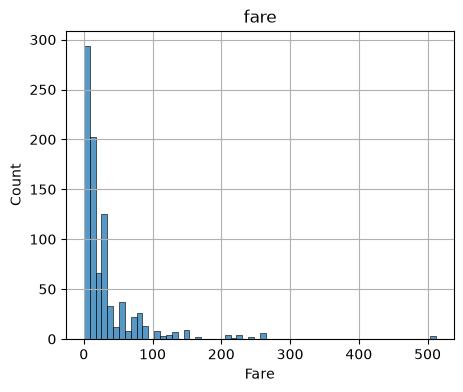

In [6]:
# a plain histogram of Fare, with a size and a title -> histplot 
plt.figure(figsize=(5,4))
sns.histplot(data=df,x='Fare')
plt.title("fare")
plt.grid()
plt.show()

In [ ]:
# save that same chart as a file


`plt.savefig('name.png')` must come **before** `plt.show()` — after it, the figure is gone.

---
# 1️⃣ Univariate — one column at a time

**The question:** can I use this feature at all?

### `histplot` — how is one number spread out?

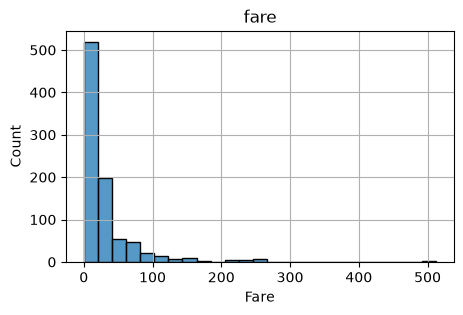

In [15]:
# distribution of Fare
plt.figure(figsize=(5,3))
sns.histplot(data=df,x='Fare',bins=25)
plt.title("fare")
plt.grid()
plt.show()

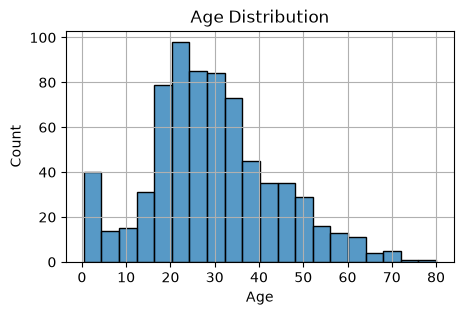

In [17]:
# distribution of Age
plt.figure(figsize=(5,3))
sns.histplot(data=df,x='Age',bins=20)
plt.title("Age Distribution")
plt.grid()
plt.show()

| | mean | median | max |
|---|---|---|---|
| Fare | 32.20 | **14.45** | 512 |
| Age | 29.70 | 28.00 | 80 |

`Fare` has a long tail to the right — a few people paid enormous amounts and dragged the
mean above the median. `Age` is roughly symmetric.

⭐ **The shape decides your fill.** Long tail → median. Symmetric → either works.

### `countplot` — how many in each category?

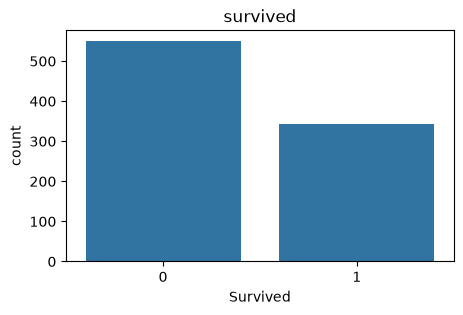

In [19]:
# how many survived and how many died
plt.figure(figsize=(5,3))
sns.countplot(data=df,x='Survived')
plt.title("survived")
plt.show()

**549 died, 342 survived** — that is **61.6%**.

⭐ A model that always predicts "died" scores 61.6% without learning anything.
Any accuracy below that is worse than saying nothing.

### 🧩 Try these — on `mpg.csv`

**Q1** Plot the distribution of `mpg`. Is it skewed? If this column had blanks, would you
fill with the mean or the median?

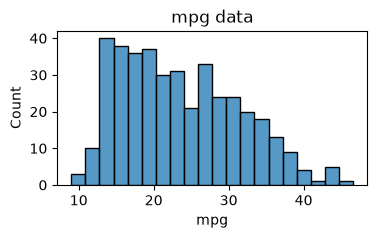

In [20]:
# Q1
plt.figure(figsize=(4,2))
sns.histplot(data=mpg,x='mpg',bins=20)
plt.title("mpg data")
plt.show()

**Q2** How many cars come from each `origin`? What would that imbalance do to a model
trained on this data?

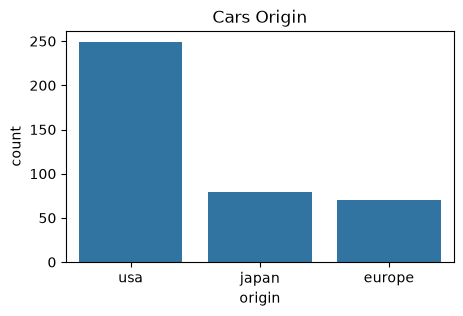

In [30]:
# Q2
plt.figure(figsize=(5,3))
sns.countplot(data=mpg,x='origin')
plt.title("Cars Origin")
plt.show()

---
# 2️⃣ Bivariate — two columns together

**The question:** does this feature separate the thing I am predicting?

### `boxplot` — does a number differ across groups?

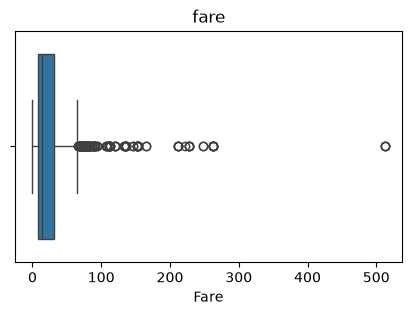

In [35]:
# Fare on its own — read the box, the whiskers, the dots
plt.figure(figsize=(5,3))
sns.boxplot(data=df,x='Fare')
plt.title("fare")
plt.show()

The box is the middle half of the data. The line inside is the median. The dots beyond the
whiskers are outliers — `Fare` has **116** of them.

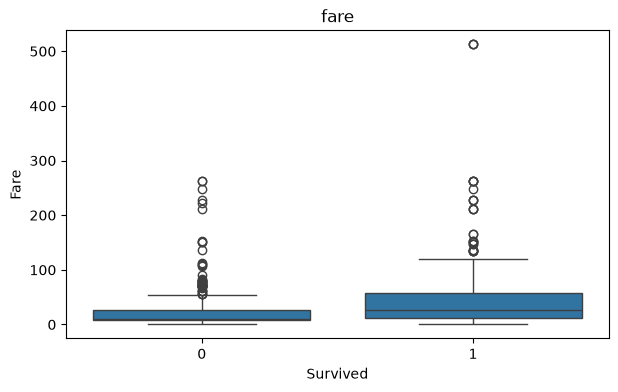

In [38]:
# Fare split by Survived
plt.figure(figsize=(7,4))
sns.boxplot(data=df,x='Survived',y='Fare')
plt.title("fare")
plt.show()

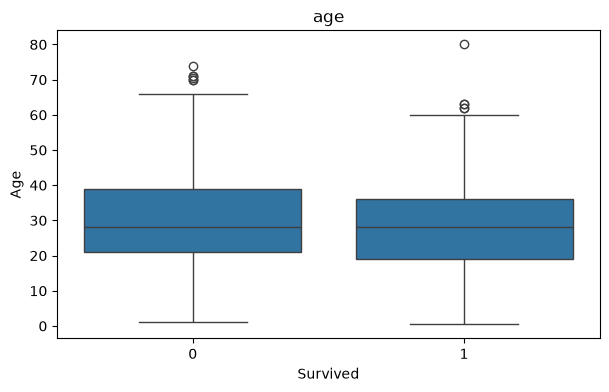

In [40]:
# Age split by Survived
plt.figure(figsize=(7,4))
sns.boxplot(data=df,x='Survived',y='Age')
plt.title("age")
plt.show()

| | died | survived |
|---|---|---|
| median `Fare` | 10.50 | **26.00** |
| median `Age` | 28.0 | 28.0 |

⭐ `Fare` separates the two groups. `Age` does not. **A feature that does not separate
your classes will not help your model.**

### `scatterplot` — do two numbers move together?

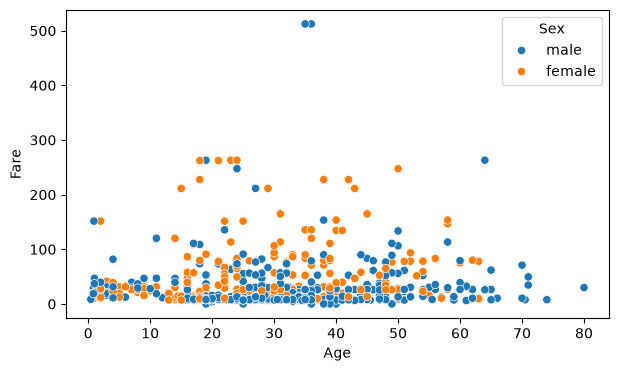

In [44]:
# Age against Fare
plt.figure(figsize=(7,4))
sns.scatterplot(data=df,x='Age',y='Fare',hue="Sex")
plt.show()

A shapeless cloud. These two columns barely relate — the correlation is only 0.096.

### `hue=` — the argument that turns any plot into an ML plot

Add one word and the target appears inside the picture.

In [ ]:
# the same scatter, coloured by Survived
plt.figure(figsize=)

In [ ]:
# and a countplot of Pclass, coloured by Survived


The scatter now shows where survivors sit. The countplot shows both the survival split
**and** the group sizes at once — 216, 184, **491**.

⭐ That is the "read the group size next to the group average" rule from last week,
drawn instead of calculated.

### 🧩 Try these — on `mpg.csv`

**Q3** Boxplot `mpg` split by `origin`, then split by `cylinders` instead.
Which of the two separates the groups more clearly?

In [ ]:
# Q3

**Q4** Scatter `weight` against `mpg`, coloured by `origin`.
Describe the relationship in one line, and say what the colours add.

In [41]:
# Q4
#plt.figure(figsize=(6,4))
#sns.scatterplot(data=mpg, x='weight', y='mpg', hue='origin')
#plt.title("Weight vs MPG")
#plt.show()

---
# 3️⃣ Multivariate — everything at once

**The question:** which features matter, and which ones repeat each other?

### `pairplot` — every pair of columns in one grid

In [ ]:
# pairplot of Age, Fare, Pclass and Survived, coloured by Survived



In [ ]:
# pairplot of total_bil,age and size diag_kind is hist colored by sex

Scatter plots off the diagonal, distributions along it. Univariate and bivariate in a
single line.

⚠️ `pairplot` builds its own figure, so `plt.figure(figsize=...)` has no effect on it.
Use `height=` instead. It is also slow on wide tables — pick your columns first.

### `heatmap` — the same idea as numbers

In [ ]:
# correlation of the numeric columns


In [ ]:
# the same thing as a heatmap, with the numbers written on it

Correlation with `Survived`:

| feature | correlation |
|---|---|
| `Pclass` | **−0.34** |
| `Fare` | 0.26 |
| `Parch` | 0.08 |
| `Age` | −0.08 |

⭐ A heatmap does two jobs: it shows **what predicts your target**, and it shows
**which features are duplicates of each other**.

### 🧩 Try this — on `mpg.csv`

**Q5** ⭐ Heatmap of the numeric columns in `mpg`. Two parts:

1. Which feature predicts `mpg` best?
2. Find two features that are almost the same thing — if you had to drop one, which
   and why?

In [ ]:
# Q5

---
## 📌 Which plot, when

| Your question | Columns | Plot |
|---|---|---|
| How is one number spread out? | 1 numeric | `histplot` |
| How many in each category? | 1 categorical | `countplot` |
| Does this number differ across groups? | numeric + categorical | `boxplot` |
| Do two numbers move together? | 2 numeric | `scatterplot` |
| *…and does the target split them?* | **+ target** | **add `hue=`** |
| Quick look at everything | many numeric | `pairplot` |
| Which features matter, which repeat? | many numeric | `heatmap` |

### The skeleton
```python
plt.figure(figsize=(7, 4))
sns.histplot(data=df, x='column')
plt.title('...')
plt.show()
```

### What each plot decided today
- `Fare` is skewed → **fill with the median**
- 61.6% died → **any model must beat 61.6%**
- `Fare` separates survivors, `Age` does not → **keep Fare, question Age**
- `Pclass` correlates −0.34 with survival → **the strongest single number you have**